# Q-Learning in Cliff Walking-version0(non slippery)<br>
In this the virtual enviroment is already made in the Gymnasium library.We just simply import it and do Q-Learning on it.<br>
![Cliff Walking](CliffWalking.png)<br>
This is how it actually looks and the aim is to reach bottom right from bottom left while avoiding the cliff.Every step results in a -1 reward except the bottom right where the reward is 0.Falling in the cliff gives a -100 reward and terminates the episode.Also going to bottom right terminates the episode.This structure of rewarding makes the RL learn the shortest path to the destination while avoiding the cliff.

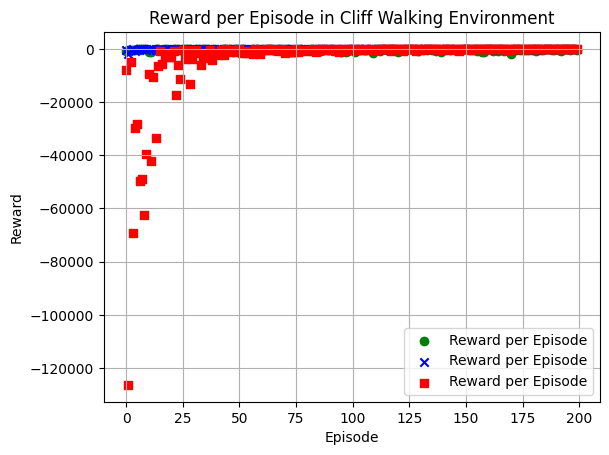

In [ ]:
import numpy as np
import gymnasium as gym
from gymnasium.envs.toy_text.cliffwalking import CliffWalkingEnv
import matplotlib.pyplot as plt
#  Initialize the Environment this initializing was giving a depreciation error but I looked it up on an AI the way to export the environment has changed but the rest is the same
env = CliffWalkingEnv()
#  Hyperparameters
alpha = 0.1         
gamma = 0.99        
epsilon1 = 0.05      
epsilon2 = 0.5
epsilon3initial = 1.0
epsilon3final = 0.01
episodes = 200     

# Initialize Q-Table
num_states = env.observation_space.n
num_actions = env.action_space.n
q_table = np.zeros((num_states, num_actions))
reward_ateach_episode_e1 = np.zeros(episodes, dtype=int) 
reward_ateach_episode_e2 = np.zeros(episodes, dtype=int) 
reward_ateach_episode_e3 = np.zeros(episodes, dtype=int) 

def choose_action(state, epsilon):
    if np.random.uniform(0, 1) < epsilon:
        return env.action_space.sample() # Explore
    else:
        return np.argmax(q_table[state, :]) # Exploit
#For epsilon 1 =0.05
for episode in range(episodes):
    state, info = env.reset()
    done = False
    total_reward = 0
    
    while not done:
        action = choose_action(state, epsilon1)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward
        
        
        # Q-Learning update rule
        best_next_action = np.argmax(q_table[next_state, :])
        td_target = reward + gamma * q_table[next_state, best_next_action]
        td_error = td_target - q_table[state, action]
        q_table[state, action] += alpha * td_error
        state = next_state
    reward_ateach_episode_e1[episode] = total_reward
#For epsilon 2 =0.5
for episode in range(episodes):
    state, info = env.reset()
    done = False
    total_reward = 0
    
    while not done:
        action = choose_action(state, epsilon2)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward
        
        
        # Q-Learning update rule
        best_next_action = np.argmax(q_table[next_state, :])
        td_target = reward + gamma * q_table[next_state, best_next_action]
        td_error = td_target - q_table[state, action]
        q_table[state, action] += alpha * td_error
        state = next_state
    reward_ateach_episode_e2[episode] = total_reward    
#For epsilon 3 = decreasing from 1.0 to 0.01
for episode in range(episodes):
    state, info = env.reset()
    done = False
    total_reward = 0
    
    while not done:
        action = choose_action(state, epsilon3initial - (epsilon3initial - epsilon3final) * episode / episodes)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward
        
        
        # Q-Learning update rule
        best_next_action = np.argmax(q_table[next_state, :])
        td_target = reward + gamma * q_table[next_state, best_next_action]
        td_error = td_target - q_table[state, action]
        q_table[state, action] += alpha * td_error
        state = next_state
    reward_ateach_episode_e3[episode] = total_reward  
plt.scatter(range(len(reward_ateach_episode_e2)), reward_ateach_episode_e2, marker='o', linestyle='-', color='g', label='Reward per Episode')
plt.scatter(range(len(reward_ateach_episode_e1)), reward_ateach_episode_e1, marker='x', linestyle='-', color='b', label='Reward per Episode')
plt.scatter(range(len(reward_ateach_episode_e3)), reward_ateach_episode_e3, marker='s', linestyle='-', color='r', label='Reward per Episode')
# 3. Add labels and a grid so it's easy to read
plt.title('Reward per Episode in Cliff Walking Environment')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.grid(True)
plt.legend()

# 4. Show the plot
plt.show()
env.close()

